In [39]:
import numpy as np
import matplotlib.pyplot as plt
import re

F-Function

In [40]:
import itertools
from scipy import special as sp

'''
Finite-volume function
'''

twoPi = 2.0 * np.pi


# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor

# sqrt with branch cut aligned on positive real axis
def mySqrt(z):
   return 1j * np.sqrt( -z )

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * float(m) **2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)


def inner1d(A, B):
   return np.sum( A * B, axis=1)


# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function( Ecm, nP, alpha, L):
    P = twoPi * nP / L                               # P = (2*pi/L)* nP
    P_sq = np.dot(P,P)                              # P^2
    E = np.sqrt( Ecm**2 + P_sq )                    # compute E given Ecm and P
    s = Ecm**2
    eps = 1e-16
    qcm = q_cm(s+1j*eps)
    qcm_sq = qcm**2
    rho = phase_space(s+1j*eps)
    beta = P/E                                      # boost velocity

    m_sq = m**2

    k = (twoPi / L) * intList
    omega = np.sqrt( m_sq + inner1d(k,k) )
    omega_cm, k_cm = lorentzBoost( omega, k, beta )
    tmp = cutoff( qcm_sq, inner1d(k_cm,k_cm), alpha, L ) * omega_cm / omega
    tmp = tmp / ( qcm_sq - inner1d(k_cm,k_cm ) )
    sum0 = ( xi / (2.0 * Ecm * L**3) ) * np.sum( tmp )

    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    z   = np.sqrt( alpha ) * qcm
    integral = ( xi / (4.0 * np.pi**2 * Ecm )) * ( ( np.sqrt( 0.25 * np.pi / alpha ) ) * np.exp( alpha * qcm_sq ) - 0.5 * np.pi * qcm * sp.erfi( z ) )

    return  1j * rho + sum0.real + integral # taking real part of sum to remove imaginary artifact at threshold



Various Constants

In [82]:
nShell = 15
alpha = 0.125
m = 1.0  #might need to be changed?
am_pi = 0.310810
am_N = 0.70266


intList = generateIntList( nShell )

pole_gap = 3e-3

Psq_to_nP = {
    0:np.array([0,0,0]),
    1:np.array([0,0,1]),
    2:np.array([0,1,1]),
    3:np.array([1,1,1]),
    4:np.array([0,0,2])
}

L_values = [48*am_N]

E_min = 1.950
E_max = 2.080
Ecm_grid = np.linspace(E_min, E_max, 550)

a_r_Values = np.array([[1,1],[-7.46,-9.72]])





Fake Energy Levels 

In [83]:
pole_cache = {}


def free_particle_poles(nP, L, m, E_min, E_max, maxShell=15):
    punit_ = 2*np.pi/L
    nP_arr = np.array(nP, dtype=float)
    Pvec = punit_*nP_arr
    P2_ = np.dot(Pvec, Pvec)
    levels = []
    for i in range(-maxShell, maxShell+1):
        for j in range(-maxShell, maxShell+1):
            for k in range(-maxShell, maxShell+1):
                n1 = np.array([i,j,k]); n2 = nP_arr - n1
                p1, p2 = punit_*n1, punit_*n2
                E_lab = float(np.sqrt(p1@p1+m**2) + np.sqrt(p2@p2+m**2))
                E_cm_sq = E_lab**2 - P2_
                if E_cm_sq <= 0:
                    continue
                E_cm = np.sqrt(E_cm_sq)
                if E_min - 0.05 < E_cm < E_max + 0.05:
                    levels.append(E_cm)
    return np.unique(np.round(levels, 10))


def free_particle_poles_cached(nP, L, m, E_min, E_max, maxShell=15):
    key = (tuple(nP), L, m, E_min, E_max, maxShell)
    if key not in pole_cache:
        raw = free_particle_poles(nP, L, m, E_min, E_max, maxShell)

        if len(raw) == 0:
            pole_cache[key] = raw
        else:
            unique = [raw[0]]
            for p in raw[1:]:
                if abs(p - unique[-1]) > 1e-5:
                    unique.append(p)
            pole_cache[key] = np.array(unique, dtype=float)
    return pole_cache[key]



In [84]:
def mySqrt_vectorized(z):
    z = np.asarray(z, dtype=complex)
    return 1j * np.sqrt(-z)

def q_cm_vectorized(s):
    return 0.5 * mySqrt_vectorized(s - 4.0 * m**2)


def M_using_a_r(Ecm, a, r): 
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    effective_range = (-1/a) + 0.5 * r * (qcm**2)
    return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

# def quantization_condition(Ecm, a, r, nP,L):
#     # eps = 1e-16
#     # s = Ecm**2 + 1j*eps
#     # qCotDelta = -1/a + 0.5*r*q_cm(s)**2
#     # Kinverse = xi * qCotDelta / (8*np.pi*Ecm)   <----- 2 ways to implment quantization condition. Comment out 1
#     # Fpv = F_function(Ecm, nP, alpha, L).real   
#     # return (Kinverse + Fpv).real
   
   
#     FValues = F_function(Ecm,nP,alpha,L)
#     MValues = M_using_a_r(Ecm,a,r)                 #<----- 2 ways to implment quantization condition. Comment out 1
#     return np.real(1/MValues + FValues)

In [85]:


# def find_zeros_in_grid(quantization_values, energies, poles,Psq):
#     zeros = []
#     for i in range(len(energies) - 1):
#         f1, f2 = quantization_values[i], quantization_values[i+1]
#         e1, e2 = energies[i], energies[i+1]
#         if not (np.isfinite(f1) and np.isfinite(f2)):
#             continue
#         if np.sign(f1) == np.sign(f2):
#             continue
#         if np.any((poles >= e1) & (poles <= e2)):
#             continue   
#         slope = (f2 - f1) / (e2 - e1)

#         root = e1 - f1/slope
#         if np.any(np.abs(root - poles) < pole_gap):
#             continue


#         zeros.append(e1 - f1/slope)
    # return np.array(zeros)

def find_zeros_in_grid(quantization_values, energies, poles, Psq):
    f1, f2 = quantization_values[:-1], quantization_values[1:]
    e1, e2 = energies[:-1], energies[1:]

    mask = np.isfinite(f1) & np.isfinite(f2) & (np.sign(f1) != np.sign(f2))

    if len(poles) > 0 and mask.any():
        idxs = np.where(mask)[0]
        bracket_has_pole = np.zeros(len(idxs), dtype=bool)
        for p in poles:                       # loop over poles (small, ~5-15), not grid points
            bracket_has_pole |= (p >= e1[idxs]) & (p <= e2[idxs])
        mask[idxs] &= ~bracket_has_pole

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.array([])

    slope = (f2[idx] - f1[idx]) / (e2[idx] - e1[idx])
    roots = e1[idx] - f1[idx]/slope

    if len(poles) > 0 and len(roots) > 0:
        dists = np.abs(roots[:, None] - poles[None, :])
        keep = np.all(dists >= pole_gap, axis=1)
        roots = roots[keep]

    return roots


In [86]:
F_by_Psq = {}
for L in L_values:
    for Psq_tot, nP in Psq_to_nP.items():
        F_by_Psq[(L, Psq_tot)] = np.array([
            F_function(Ecm, nP, alpha, L) for Ecm in Ecm_grid
        ])

#test code, not ever used
# def spectrum_from_ar(a, r, L, Psq_tot):
#     Q = quantization_grid(a, r, L, Psq_tot)
#     poles = free_particle_poles_cached(Psq_to_nP[Psq_tot], L, m)
#     return find_zeros_in_grid(Q, Ecm_grid, poles, Psq_tot)

def quantization_grid(a, r, L, Psq_tot):
    M_values = M_using_a_r(Ecm_grid, a, r)
    F_values = F_by_Psq[(L, Psq_tot)]
    return np.real(1.0 / M_values + F_values)

In [87]:

sigma_E = 0.010 #the uncertainty, acts as noise
rng = np.random.default_rng()


def generate_spectrum(i, L_values, Psq_to_nP, E_min, E_max, sigma_E):
    rows = [] #the "observed" data, is noisy
    true_rows = [] #the actual data values, to check with.only exists for valdiation
    a,r = a_r_Values[i]

    for L in L_values:
        for Psq, nP in Psq_to_nP.items():
            Q = quantization_grid(a, r, L, Psq)
            poles = free_particle_poles_cached(nP, L, m, E_min, E_max)
            E_true_levels = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

            for level_index, E_true in enumerate(E_true_levels):
                E_obs = E_true + rng.normal(0.0, sigma_E)       
                row = {
                    "L": float(L),
                    "Psq": Psq,
                    "level_index": level_index,
                    "E_true": float(E_true),
                    "E_obs": float(E_obs),
                    "dE": sigma_E,
                }

                rows.append(row)
                true_rows.append(row.copy())

    data = rows
    print(f"generated {len(data)} finite-volume levels across {len(L_values)} volumes and {len(Psq_to_nP.keys())} frames")
    return data 


In [88]:
def generate_spectrum_covariance(i, L_values, Psq_to_nP, E_min, E_max, sigma_E):
    rows = [] #the "observed" data, is noisy
    true_rows = [] #the actual data values, to check with.only exists for valdiation
    a,r = a_r_Values[i]

    for L in L_values:
        for Psq, nP in Psq_to_nP.items():
            Q = quantization_grid(a, r, L, Psq)
            poles = free_particle_poles_cached(nP, L, m, E_min, E_max)
            E_true_levels = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

            for level_index, E_true in enumerate(E_true_levels):
                E_obs = E_true + rng.normal(0.0, sigma_E)       
                row = {
                    "L": float(L),
                    "Psq": Psq,
                    "level_index": level_index,
                    "E_true": float(E_true),
                }

                rows.append(row)
                true_rows.append(row.copy())
    Etrue = np.array([row["E_true"] for row in rows])
    num_bootstrap = 5000
    num_levels = len(Etrue)
    sigma_true = np.linspace(0.006,0.014, num_levels)
    rho = 0.6
    scale = rho**np.abs(np.subtract.outer(np.arange(num_levels), np.arange(num_levels)))
    covariance_matrix = np.outer(sigma_true, sigma_true) * scale

    Eboot = rng.multivariate_normal(Etrue, covariance_matrix, size=num_bootstrap)
    Ecm_Covariance = np.cov(Eboot, rowvar=False, ddof = 0)

    Eobs = np.mean(Eboot, axis=0)

    for j,row in enumerate(rows):
        row["E_obs"] = float(Eobs[j])
        row["index"] = j
        row["dE"] = float(np.sqrt(Ecm_Covariance[j,j]))
    data = rows
    print(f"generated {len(data)} finite-volume levels across {len(L_values)} volumes and {len(Psq_to_nP.keys())} frames")
    return data 

generated 3 finite-volume levels across 1 volumes and 5 frames
generated 13 finite-volume levels across 1 volumes and 5 frames
generated 13 finite-volume levels across 1 volumes and 5 frames


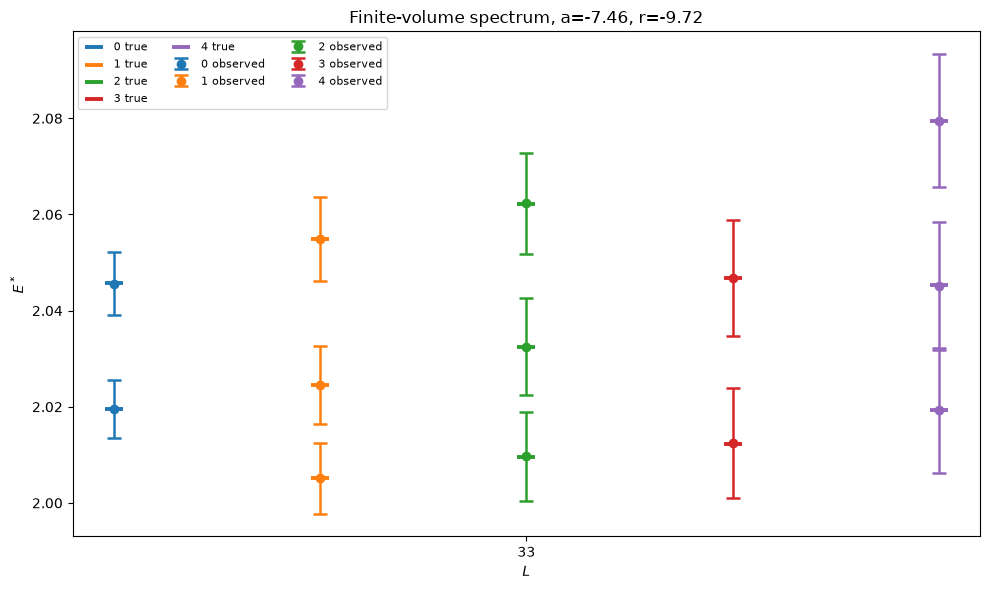

In [89]:
Psq_offsets = {0: -0.2, 1: -0.1, 2: 0.0, 3: 0.1, 4: 0.2}

def plot_spectrum(level_rows, i, include_observed=True, include_true=True, predicted_rows=None):
    plt.figure(figsize=(10, 6))
    for Psq in Psq_to_nP.keys():
        offset = Psq_offsets[Psq]
        rows_frame = [r for r in level_rows if r["Psq"] == Psq]

        if include_observed:
            x_obs = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_obs = np.array([r["E_obs"] for r in rows_frame], dtype=float)
            yerr = np.array([r["dE"] for r in rows_frame], dtype=float)

            plt.errorbar(
                x_obs,
                y_obs,
                yerr=yerr,
                fmt="o",
                markersize=6,
                capsize=5,
                capthick=1.8,
                elinewidth=1.8,
                linewidth=0,
                label=f"{Psq} observed",
                zorder=5,
            )

        if include_true:
            x_true = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_true = np.array([r["E_true"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_true,
                y_true,
                marker="_",
                s=180,
                linewidths=2.8,
                label=f"{Psq} true",
                zorder=4,
            )

    if predicted_rows is not None:
        for Psq in Psq_to_nP.keys():
            offset = Psq_offsets[Psq]
            rows_frame = [r for r in predicted_rows if r["Psq"] == Psq]
            x_pred = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_pred = np.array([r["E_pred"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_pred,
                y_pred,
                marker="x",
                s=70,
                linewidths=2.2,
                label=f"{Psq} GP",
                zorder=6,
            )

    plt.xticks(L_values, [str(int(L)) for L in L_values])
    plt.xlabel(r"$L$")
    plt.ylabel(r"$E^*$")
    plt.title(f"Finite-volume spectrum, a={a_r_Values[i][0]}, r={a_r_Values[i][1]}")

    plt.legend(ncols=3, fontsize=8)
    plt.tight_layout()
    plt.show()

data0 = generate_spectrum(0, L_values, Psq_to_nP, E_min, E_max, sigma_E)
data1 = generate_spectrum(1, L_values, Psq_to_nP, E_min, E_max, sigma_E)
#plot_spectrum(data0, 0)
#plot_spectrum(data1, 1)

# data0_cov = generate_spectrum_covariance(0, L_values, Psq_to_nP, E_min, E_max, sigma_E)
data1_cov = generate_spectrum_covariance(1, L_values, Psq_to_nP, E_min, E_max, sigma_E)
# plot_spectrum(data0_cov, 0)
plot_spectrum(data1_cov, 1)

In [90]:
def group_by_Psq(data, L):
    
    grouped = {Psq: [] for Psq in Psq_to_nP.keys()}
    for row in data:
        if row["L"] == float(L):
            grouped[row["Psq"]].append(row["E_true"])
    return {Psq: np.array(levels) for Psq, levels in grouped.items()}

for i in range(len(a_r_Values)):
    a, r = a_r_Values[i]
    data = data1_cov
    print(f"\n=== a={a}, r={r} ===")
    for L in L_values:
        by_Psq = group_by_Psq(data, L)
        print(f"  L = {L}")
        for Psq, levels in by_Psq.items():
            print(f"    Psq={Psq}: {levels}")




=== a=1.0, r=1.0 ===
  L = 33.72768
    Psq=0: [2.01953753 2.04564685]
    Psq=1: [2.00508982 2.02449647 2.05486482]
    Psq=2: [2.00958782 2.03238958 2.06214936]
    Psq=3: [2.01228061 2.04682035]
    Psq=4: [2.01938296 2.04523229 2.07951279]

=== a=-7.46, r=-9.72 ===
  L = 33.72768
    Psq=0: [2.01953753 2.04564685]
    Psq=1: [2.00508982 2.02449647 2.05486482]
    Psq=2: [2.00958782 2.03238958 2.06214936]
    Psq=3: [2.01228061 2.04682035]
    Psq=4: [2.01938296 2.04523229 2.07951279]


Gaussian Process Regression 

In [91]:
def combine_levels(Eboot, level_keys, groups, weights=None):
    """
    Combine multiple degenerate/matched levels into fewer inputs, averaging
    WITHIN each bootstrap replica so correlations are correctly propagated
    (matching Fig. 11's procedure: 'weights act on E_lab within each
    bootstrap replica before conversion').

    Eboot       : (N_boot, n_total) array, one row per bootstrap replica
    level_keys  : list of (L, Psq, level_index) matching Eboot's columns
    groups      : list of lists of column-indices to combine, e.g.
                  [[0, 1], [2], [3], [4, 5]]  -- indices 0&1 combined,
                  2 and 3 left alone, 4&5 combined
    weights     : optional list, one entry per group, giving per-member
                  weights (e.g. irrep dimension); None -> equal weights

    Returns:
        Eboot_combined : (N_boot, n_groups) reduced bootstrap ensemble
        Eobs_combined  : (n_groups,) combined central values
        CovE_combined  : (n_groups, n_groups) combined covariance matrix
        combined_labels: which original level_keys went into each new entry
    """
    N_boot = Eboot.shape[0]
    n_groups = len(groups)
    Eboot_combined = np.zeros((N_boot, n_groups))
    combined_labels = []

    for g, idxs in enumerate(groups):
        if weights is not None and weights[g] is not None:
            w = np.asarray(weights[g], dtype=float)
        else:
            w = np.ones(len(idxs))
        w = w / w.sum()
        Eboot_combined[:, g] = Eboot[:, idxs] @ w
        combined_labels.append(tuple(level_keys[i] for i in idxs))

    Eobs_combined = Eboot_combined.mean(axis=0)
    CovE_combined = np.cov(Eboot_combined, rowvar=False, ddof=0)

    return Eboot_combined, Eobs_combined, CovE_combined, combined_labels

Building my own GP implementation 

Stage 1.
    - vector of knots
    - builds nxn kernel matrix, given hyperparamters
    - adds small jitter term

In [92]:
num_knots = 7 
knots = np.linspace(E_min,E_max,num_knots) # knots ->x
Ecm_grid = np.linspace(E_min,E_max,550) # grid ->x. 

def RBC_kernel(x,y,sigma,length_scale): # kernel matrix 
    x=np.asarray(x).reshape(-1,1)
    y=np.asarray(y).reshape(-1,1)
    return sigma**2 * np.exp(-0.5 * (np.abs(x-y.T)**2) / length_scale**2)

def Matern_kernel(x, y, sigma, length_scale, nu=0.5 ):
    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(-1,1)
    r = np.sqrt(np.abs(x - y.T))
    if nu == 0.5:
        return sigma**2 * np.exp(-r / length_scale)
    elif nu == 1.5:
        return sigma**2 * (1 + np.sqrt(3) * r / length_scale) * np.exp(-np.sqrt(3) * r / length_scale)
    elif nu == 2.5:
        return sigma**2 * (1 + np.sqrt(5) * r / length_scale + 5 * r**2 / (3 * length_scale**2)) * np.exp(-np.sqrt(5) * r / length_scale)


def kernel_matrix(x, y, sigma, length_scale, kernel_func = RBC_kernel): 
    k =  kernel_func(x, y, sigma, length_scale) + np.eye(num_knots) * 1e-8 
    sign, logdet = np.linalg.slogdet(k)
    if sign <= 0:
        raise np.linalg.LinAlgError("GP covariance is not positive definite")

    K_inv = np.linalg.inv(k)
    interp_grid = kernel_func(Ecm_grid, knots , sigma, length_scale) @ K_inv                        

    return k, K_inv, logdet, interp_grid



Stage 2.
    -

In [93]:
# def k_inv_Grid(Ecm, sigma, length_scale, f_values): #we are deliberately not using the covariance term
#     k, k_inv, logdet, interp_grid = kernel_matrix(knots,knots,sigma,length_scale)
#     k_inv_grid = interp_grid @ f_values
#     return k_inv_grid

def Kinv_Grid(Ecm, sigma, length_scale, f_values): #we are deliberately not using the covariance term
    k, k_inv, logdet, interp_grid = kernel_matrix(knots,knots,sigma,length_scale)
    Kinv_grid = interp_grid @ f_values
    return Kinv_grid


Stage 3:
Using GP curve in place of ERE in Luscher Quantization Formula

In [94]:
def find_Zeros_GPR(f_values, sigma, length_scale, L,Psq, Kinv_grid):
    Q = np.real(Kinv_grid + F_by_Psq[(L, Psq)])
    poles = free_particle_poles_cached(Psq_to_nP[Psq], L, 1.0 , E_min, E_max)
    zeros = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)
    return zeros


Stage 4

In [95]:
def build_observed_cache(data):
    """
    Group observed synthetic levels by (L, Psq) sector, once, so the
    likelihood function can look them up instantly on every MCMC call
    instead of re-filtering the full dataset each time.

    Returns:
        dict keyed by (L, Psq) -> {"E_obs": np.array, "dE": np.array}
    """
    cache = {}
    for row in data:
        key = (row["L"], row["Psq"])
        if key not in cache:
            cache[key] = {"E_obs": [], "dE": []}
        cache[key]["E_obs"].append(row["E_obs"])
        cache[key]["dE"].append(row["dE"])

    for key in cache:
        cache[key]["E_obs"] = np.array(cache[key]["E_obs"])
        cache[key]["dE"] = np.array(cache[key]["dE"])

    return cache


observed_cache_0 = build_observed_cache(data0)   
observed_cache_1 = build_observed_cache(data1)   

# observed_cache_0_cov = build_observed_cache(data0_cov)   # a=1, r=1
observed_cache_1_cov = build_observed_cache(data1_cov)   # a=2, r=0
big_penalty = -1e6
count_mismatch_penalty = -25.0 

def log_likelihood(f_values, sigma, length_scale, observed_cache,Kinv):
    loglike = 0.0
    for L in L_values:
        for Psq in Psq_to_nP.keys():
            key = (L, Psq)
            if key not in observed_cache:
                continue  

            E_obs_arr = observed_cache[key]["E_obs"]
            dE_arr = observed_cache[key]["dE"]

            E_pred_arr = find_Zeros_GPR(f_values, sigma, length_scale, L, Psq, Kinv)

            for E_obs, dE in zip(E_obs_arr, dE_arr):
                if len(E_pred_arr) == 0:
                    loglike += big_penalty   
                    continue
                E_pred = E_pred_arr[np.argmin(np.abs(E_pred_arr - E_obs))] #nearest neightbor matching, might need to be changed 
                pull = (E_obs - E_pred) / dE
                loglike += -0.5 * pull**2 

            n_extra_or_missing = abs(len(E_pred_arr) - len(E_obs_arr))
            loglike += count_mismatch_penalty * n_extra_or_missing
    return loglike
    
    

Stage 5:

In [96]:
def log_prior(f_values, sigma, length_scale):
    C, C_inv, logdet, _ = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior = -0.5 * f_values.T @ C_inv @ f_values - 0.5 * logdet - (num_knots / 2) * np.log(2 * np.pi)
    return log_prior

#TODO choose better limit endpoints 
sigma_min, sigma_max = 0.001, 0.05
lc_min, lc_max = 0.25, 1.0

def log_hyperprior(sigma, length_scale):
    if not (sigma_min <= sigma <= sigma_max and lc_min <= length_scale <= lc_max):
        return -np.inf
    return -np.log(sigma_max - sigma_min) - np.log(lc_max - lc_min)

def log_posterior(f_values, sigma, length_scale, observed_cache):
    '''
    log_hyperprior_val = log_hyperprior(sigma, length_scale)
    if not np.isfinite(log_hyperprior_val):
        return -np.inf
    log_prior_val = log_prior(f_values, sigma, length_scale)
    log_likelihood_val = log_likelihood(f_values, sigma, length_scale, observed_cache)
    '''
    C, C_inv, logdet, interp_grid = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior_val = -0.5 * f_values.T @ C_inv @ f_values - 0.5*logdet - 0.5*num_knots *np.log(2*np.pi)

    Kinv = Kinv_Grid(Ecm_grid, sigma, length_scale, f_values)
    log_likelihood_val = log_likelihood(f_values, sigma, length_scale, observed_cache,Kinv)

    log_hyperprior_val = log_hyperprior(sigma, length_scale)

    return log_prior_val + log_likelihood_val + log_hyperprior_val

def posterior_components(f_values, sigma, length_scale, observed_cache):        
    C, C_inv, logdet, interp_grid = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior_val = -0.5 * f_values.T @ C_inv @ f_values - 0.5*logdet - 0.5*num_knots *np.log(2*np.pi)

    Kinv = Kinv_Grid(Ecm_grid, sigma, length_scale, f_values)
    log_likelihood_val = log_likelihood(f_values, sigma, length_scale, observed_cache, Kinv)

    log_hyperprior_val = log_hyperprior(sigma, length_scale)

    return log_prior_val, log_likelihood_val, log_hyperprior_val

Stage 6(single chain)

In [97]:
import numpy as np
rng = np.random.default_rng()

move_types = ["knot", "all_knots", "log_length_scale", "log_sigma"]


def propose_new_step(current_state, step_size):
    f_values, sigma, length_scale = current_state
    move = rng.random()
    
    if move < 0.4:
        k = rng.integers(1, len(f_values))
        f_copy = f_values.copy()
        f_copy[k] += step_size["knot"] * rng.normal()
        return (f_copy, sigma, length_scale),0.0,"knot"

    elif move < 0.7:
        f_new = f_values + step_size["all_knots"] * rng.normal(size=len(f_values))
        return (f_new, sigma, length_scale), 0.0,"all_knots"

    elif move < 0.9:
        log_length_scale_new = np.log(length_scale) + step_size["log_length_scale"] * rng.normal()
        length_scale_new = np.exp(log_length_scale_new)
        log_q_correction = np.log(length_scale_new) - np.log(length_scale)   # Hastings correction
        return (f_values, sigma, length_scale_new), log_q_correction,"log_length_scale"

    else:
        # random walk in log(sigma)
        log_sigma_new = np.log(sigma) + step_size["log_sigma"] * rng.normal()
        sigma_new = np.exp(log_sigma_new)
        log_q_correction = np.log(sigma_new) - np.log(sigma)
        return (f_values, sigma_new, length_scale), log_q_correction, "log_sigma"

def acceptance_step(current_state, log_posterior_current, log_posterior_function, step_sizes):
    proposed_state, log_q_correction, type = propose_new_step(current_state, step_sizes)
    log_posterior_proposed = log_posterior_function(*proposed_state)

    log_ratio = log_posterior_proposed - log_posterior_current + log_q_correction
    if np.log(rng.random()) < log_ratio:
        return proposed_state, log_posterior_proposed, True, type
    else:
        return current_state, log_posterior_current, False, type


In [98]:
def single_chain_mcmc(observed_cache, n_steps, burn_in):

    best_state, best_log_posterior = None, -np.inf

    accepted_by_type = {type: 0 for type in move_types}
    proposed_by_type = {type: 0 for type in move_types}

    window = 1000
    window_acc = {type: [] for type in move_types}
    window_prop = {type: 0 for type in move_types}
    window_accepted = {type: 0 for type in move_types}

    thin = 5

    samples = []
    log_post_history = []

    n_accepted = 0

    step_sizes = {
        "knot": 0.016,       
        "all_knots": 0.0025,  
        "log_length_scale": 0.022,    
        "log_sigma": 0.80}

    for attempt in range(20):
        f0 = 0.001 * rng.normal(0,1,num_knots)
        sigma0 = rng.uniform(sigma_min, sigma_max)
        length_scale0 = rng.uniform(lc_min, lc_max)
        log_post = log_posterior(f0, sigma0, length_scale0, observed_cache)
        if log_post > best_log_posterior:
            best_state, best_log_posterior = (f0, sigma0, length_scale0), log_post
        state = best_state
        log_post_current = best_log_posterior

    for step in range(n_steps):
        state, log_post_current, accepted, move_type = acceptance_step(
            state, log_post_current, 
            lambda f,s,l: log_posterior(f,s,l,observed_cache),
            step_sizes)
        if log_post_current > best_log_posterior:
            best_state, best_log_posterior = state, log_post_current

        log_post_history.append(log_post_current)


        recomputed = log_posterior(*state, observed_cache)
        if not np.isclose(log_post_current, recomputed, atol=1e-6):
            print(f"MISMATCH at step {step}: tracked={log_post_current:.4f}, recomputed={recomputed:.4f}")
        
        window_prop[move_type] += 1
        if accepted:
            window_accepted[move_type] += 1

        if step >= burn_in:
            proposed_by_type[move_type] += 1
            if accepted:
                accepted_by_type[move_type] += 1

        if (step + 1) % window == 0:
            for type in move_types:
                rate = window_accepted[type] / window_prop[type] if window_prop[type] > 0 else float('nan')
                window_acc[type].append(rate)
            window_prop = {type: 0 for type in move_types}
            window_accepted = {type: 0 for type in move_types}

        n_accepted += int(accepted)
        if step >= burn_in and step % thin == 0:
            samples.append(state)

        if (step+1) % 1000 == 0:
            acceptance_rate = n_accepted / (step+1)
            print(f"Step {step+1}/{n_steps}, acceptance rate: {acceptance_rate:.3f}")
    return samples, log_post_history, best_state, best_log_posterior, accepted_by_type, proposed_by_type, window_acc

In [99]:
# single_samples, single_history, single_best_state, single_best_post, single_accepted_by_type, single_proposed_by_type, single_window_acc = single_chain_mcmc(observed_cache_0, n_steps=3000, burn_in=2000)  


In [100]:
# print(single_proposed_by_type)

In [101]:
# total = 0
# for type in move_types:
#     proposed = single_proposed_by_type[type]
#     total += proposed
#     accepted = single_accepted_by_type[type]
#     rate = round(accepted/proposed,3)
#     print(f"Type: {type}, #proposed: {proposed} , # acceptances: {accepted}, acceptance rate: {rate}")

# print(total)
# for type in move_types:
#     plt.plot(single_window_acc[type], label=type)
# plt.xlabel("window (x500 steps)")
# plt.ylabel("acceptance rate")
# plt.legend()
# plt.show()

# plt.plot(single_history)  
# plt.xlabel("step")
# plt.ylabel("log posterior (current state)")
# plt.show()

In [102]:
# # unpack the best (MAP) sample found during the MCMC run
# best_f_knots, best_sigma, best_length_scale = single_best_state

# # --- Hidden ERE truth ---
# a_true, r_true = a_r_Values[0]   # swap index if plotting the other (a,r) pair
# q_star_sq_grid = (Ecm_grid/2)**2 - m**2
# q_cot_delta = -1/a_true + 0.5*r_true*q_star_sq_grid
# Kinv = xi * q_cot_delta / (8*np.pi*Ecm_grid)

# # --- GPR reconstruction from the single best sample ---
# gpr_curve = Kinv_Grid(Ecm_grid, best_sigma, best_length_scale, best_f_knots)

# # --- plot ---
# plt.figure(figsize=(8, 5))
# plt.plot(Ecm_grid, Kinv, label="Hidden ERE truth")
# plt.plot(Ecm_grid, gpr_curve, label="GPR reconstruction")
# plt.scatter(knots, best_f_knots, color="tab:blue", zorder=5, label="Best GP knots")

# plt.xlabel("E")
# plt.ylabel(r"$K^{-1}(E)$")
# plt.title("GPR reconstruction of $K^{-1}(E)$ with best knots/lc/sigma")
# plt.legend()
# plt.show()

In [103]:
# true_curve_at_knots = -1/a_true + 0.5*r_true*((knots/2)**2 - m**2)
# true_log_post, true_ll, true_lp = posterior_components(true_curve_at_knots, best_sigma, best_length_scale, observed_cache_0)
# print("true curve log posterior:", true_log_post)
# print("best_state log posterior:", single_best_post)

Covariance Matrix

det[K^-1 + F] = 0

Stage 6: Multi Chain:

In [104]:
betas = np.array([0.0, 0.005, 0.01, 0.02, 0.035, 0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.5, 0.65, 0.8, 1.0])
n_chains = len(betas)

def log_tempered_target(f_knots, sigma, length_scale, beta, observed_cache):
    logprior, loglike, loghyper = posterior_components(f_knots, sigma, length_scale, observed_cache)
    logpost = loglike+logprior+loghyper
    if not np.isfinite(logpost):
        return -np.inf, loglike, logprior
    return beta*loglike + logprior + loghyper, loglike, logprior #loghyper might be removable, but we keep it for now to be safe.


def initialize_chains(observed_cache):
    chains_state = []
    chains_logtarget = []
    for c in range(n_chains):
        best_state, best_posterior = None, -np.inf
        for attempt in range(20):
            f0 = 0.001*rng.normal(0,1,num_knots)
            sigma0 = rng.uniform(sigma_min, sigma_max)
            ell0 = rng.uniform(lc_min, lc_max)
            posterior, _, _ = log_tempered_target(f0, sigma0, ell0, betas[c], observed_cache)
            if posterior > best_posterior:
                best_state, best_posterior = (f0, sigma0, ell0), posterior
        chains_state.append(best_state)
        chains_logtarget.append(best_posterior)
    return chains_state, chains_logtarget

def chain_step(chain_state, chain_logtarget, beta, step_sizes, observed_cache):
    proposed_state, log_q_correction, move_type = propose_new_step(chain_state, step_sizes)
    proposed_val, loglike, logprior = log_tempered_target(*proposed_state, beta, observed_cache)

    log_ratio = proposed_val - chain_logtarget + log_q_correction

    if(np.log(rng.random()) < log_ratio):
        return proposed_state, proposed_val, True, move_type
    else:
        return chain_state, chain_logtarget, False, move_type

def try_swap(c, chains_state, chains_logtarget, betas, observed_cache):
    beta_a, beta_b = betas[c], betas[c+1]
    _, loglike_a, logprior_a = log_tempered_target(*chains_state[c], beta_a, observed_cache)
    _, loglike_b, logprior_b = log_tempered_target(*chains_state[c+1], beta_b, observed_cache)

    log_swap_ratio = (beta_a - beta_b) * (loglike_b - loglike_a)
    if(np.log(rng.random())) < log_swap_ratio:
        chains_state[c], chains_state[c+1] = chains_state[c+1], chains_state[c]
        chains_logtarget[c], _,_ = log_tempered_target(*chains_state[c], beta_a, observed_cache)
        chains_logtarget[c+1], _,_ = log_tempered_target(*chains_state[c+1], beta_b, observed_cache)
        return True
    return False

In [105]:
def run_parallel_tempering(observed_cache, n_steps, burn_in):
    cold = n_chains - 1
    thin = 5
    swap_every = 10

    print("Observed Cache: " + str(observed_cache))
    print("n_steps: " + str(n_steps))
    print("burn_in: " + str(burn_in))

    multi_chain_sizes = {
        "knot": 0.016,       
        "all_knots": 0.0025,  
        "log_length_scale": 0.022,    
        "log_sigma": 0.80}

    samples = []
    swap_attempts = np.zeros(n_chains-1)
    swap_accepts = np.zeros(n_chains-1)
    cold_log_post_history = []
    cold_accepted_by_type = {t: 0 for t in move_types}
    cold_proposed_by_type = {t: 0 for t in move_types}
    best_cold_state, best_cold_logpost = None, -np.inf

    chains_state, chains_logtarget = initialize_chains(observed_cache)

    for step in range(n_steps):
        for c in range(n_chains):
            chains_state[c], chains_logtarget[c], accepted, move_type = chain_step(
                chains_state[c], chains_logtarget[c], betas[c], multi_chain_sizes, observed_cache
            )

            if c == cold:
                cold_log_post_history.append(chains_logtarget[c])
                if chains_logtarget[c] > best_cold_logpost:
                        best_cold_state, best_cold_logpost = chains_state[c], chains_logtarget[c]
                if step >= burn_in:
                    cold_proposed_by_type[move_type] += 1
                    if accepted:
                        cold_accepted_by_type[move_type] += 1

        if((step+1) % swap_every == 0):   
            for c in range(n_chains - 1):
                swap_attempts[c] += 1
                if try_swap(c, chains_state, chains_logtarget, betas, observed_cache):
                    swap_accepts[c] += 1

        if step >= burn_in and step % thin == 0:
            samples.append(chains_state[cold])   

        if (step+1) % 1000 == 0:
            print(f"Step {step+1}/{n_steps} completed. Cold chain log posterior: {chains_logtarget[cold]:.3f}")
    print(f"Samples: {samples}")
    print(f"Swap Attempts: {swap_attempts}")
    print(f"Swap Accepts: {swap_accepts}")
    print(f"Cold Log Posterior History: {cold_log_post_history}")
    print(f"Cold Accepted by Type: {cold_accepted_by_type}")
    print(f"Cold Proposed by Type: {cold_proposed_by_type}")
    print(f"Best Cold State: {best_cold_state}")
    print(f"Best Cold Log Posterior: {best_cold_logpost}")
    return samples, swap_attempts, swap_accepts, cold_log_post_history, cold_accepted_by_type, cold_proposed_by_type, best_cold_state, best_cold_logpost

In [106]:
import itertools
m_pi = am_pi/am_N
sector_keys = [(L, Psq) for L in L_values for Psq in Psq_to_nP.keys()]
color_cycle = plt.cm.tab10.colors   
color_by_sector = {key: color_cycle[i % len(color_cycle)] for i, key in enumerate(sector_keys)}

def plot_mcmc(observed_cache, best_cold_state, cold_log_post_history, samples, best_cold_logpost):
    best_f_knots,  best_sigma ,best_length_scale= best_cold_state 

    a_true, r_true = a_r_Values[1]   
    q_star_sq_grid = (Ecm_grid/2)**2 - m**2
    q_star_sq_grid_dim = q_star_sq_grid / m_pi**2
    q_cot_delta = -1/a_true + 0.5*r_true*q_star_sq_grid
    q_cot_delta_dim = q_cot_delta / m_pi
    # Kinv = xi * q_cot_delta / (8*np.pi*Ecm_grid)
    # true_curve_at_knots = -1/a_true + 0.5*r_true*((knots/2)**2 - m**2) / qcd_conversion_knots


    plt.plot(cold_log_post_history)
    plt.xlabel("step")
    plt.ylabel("cold chain log posterior")
    plt.axhline(best_cold_logpost, color="red", linestyle="--", label="true curve")
    plt.legend()
    plt.show()




    # posterior_mean = curves.mean(axis=0)
    # lower_68 = np.percentile(curves, 16, axis=0)
    # upper_68 = np.percentile(curves, 84, axis=0)

    qcd_conversion = 8*np.pi*Ecm_grid/xi
    qcd_conversion_knots = 8*np.pi*knots/xi

    reconstructed_curve = Kinv_Grid(Ecm_grid, best_sigma, best_length_scale, best_f_knots)
    reconstructed_curves_qcd = reconstructed_curve * qcd_conversion
    best_f_knots_qcd = best_f_knots * qcd_conversion_knots

    curves = np.array([
        Kinv_Grid(Ecm_grid, sigma, length_scale, f_knots)
        for f_knots, sigma, length_scale in samples
    ])
    curves_qcd = curves * qcd_conversion

    posterior_mean_qcd = np.percentile(curves_qcd, 50, axis=0)
    lower_68_qcd = np.percentile(curves_qcd, 16, axis=0)
    upper_68_qcd = np.percentile(curves_qcd, 84, axis=0)
    knots_q_star_sq = (knots/2)**2 - m**2

    knots_q_star_sq_dim = knots_q_star_sq / m_pi**2
    reconstructed_curves_qcd_dim = reconstructed_curves_qcd / m_pi
    best_f_knots_qcd_dim = best_f_knots_qcd / m_pi
    posterior_mean_qcd_dim = posterior_mean_qcd / m_pi
    lower_68_qcd_dim = lower_68_qcd / m_pi
    upper_68_qcd_dim = upper_68_qcd / m_pi

    plt.figure(figsize=(8, 5))
    plt.plot(q_star_sq_grid_dim, q_cot_delta_dim, label="Hidden ERE truth")
    plt.plot(q_star_sq_grid_dim, reconstructed_curves_qcd_dim, label="Reconstructed curve")
    plt.xlabel(r"$q^{*2} / m_\pi^2$")
    plt.scatter(knots_q_star_sq_dim, best_f_knots_qcd_dim, zorder=5)
    plt.ylabel(r"$q^*\cot\delta / m_\pi$")
    plt.title(r"$q^*\cot\delta / m_\pi$ reconstruction")
    # plt.xlim(-0.02,0.20)
    plt.legend()
    plt.show()




    plt.figure(figsize=(8, 5))
    plt.plot(q_star_sq_grid_dim, q_cot_delta_dim, label="Hidden ERE truth")
    plt.plot(q_star_sq_grid_dim, posterior_mean_qcd_dim, label="Posterior mean")
    plt.plot(q_star_sq_grid_dim, reconstructed_curves_qcd_dim, label="Reconstructed curve")
    plt.fill_between(q_star_sq_grid_dim, lower_68_qcd_dim, upper_68_qcd_dim, alpha=0.3, label="68% interval")
    plt.scatter(knots_q_star_sq_dim, best_f_knots_qcd_dim, zorder=5, color="tab:orange")
    # for row in data0:
    #     E = row["E_obs"]
    #     q_sq = (E/2)**2 - m**2
    #     nP = Psq_to_nP[row["Psq"]]
    #     L = row["L"]
    #     qcd = get_q_cot_delta(E, nP, alpha, L)
    #     plt.scatter(q_sq, qcd, color=color_by_sector[(L, row["Psq"])])
    plt.xlabel(r"$q^{*2} / m_\pi^2$")
    plt.ylabel(r"$q^*\cot\delta / m_\pi$")
    plt.title(r"Posterior median and 68% interval for $q^*\cot\delta$")
    # plt.xlim(-0.02,0.20)
    plt.legend()
    plt.show()

    
    # edge_curves = curves[:, :20]  # first ~20 grid points near q*²=0
    # print(edge_curves.min(), edge_curves.max())
    # plt.hist(edge_curves[:, 0], bins=50)  # distribution of samples at the very first grid point
    # plt.show()

In [107]:
# (samples_diag, swap_attempts_diag, swap_accepts_diag, cold_log_post_history_diag,
#  cold_accepted_by_type_diag, cold_proposed_by_type_diag, best_cold_state_diag, best_cold_logpost_diag
# ) = run_parallel_tempering(observed_cache_0, n_steps=25000, burn_in=3000)



In [108]:
# plot_mcmc(observed_cache_0, best_cold_state_diag, cold_log_post_history_diag, samples_diag)

In [ ]:
(samples_cov, swap_attempts_cov, swap_accepts_cov, cold_log_post_history_cov,
 cold_accepted_by_type_cov, cold_proposed_by_type_cov, best_cold_state_cov, best_cold_logpost_cov
) = run_parallel_tempering(observed_cache_1_cov, n_steps=35000, burn_in=7500)

Observed Cache: {(33.72768, 0): {'E_obs': array([2.01954034, 2.04563444]), 'dE': array([0.00594374, 0.00658745])}, (33.72768, 1): {'E_obs': array([2.00511394, 2.02449786, 2.05490175]), 'dE': array([0.0073178 , 0.00816829, 0.00866473])}, (33.72768, 2): {'E_obs': array([2.00966687, 2.03248605, 2.06229462]), 'dE': array([0.00934517, 0.0100612 , 0.0105815 ])}, (33.72768, 3): {'E_obs': array([2.01244309, 2.04676124]), 'dE': array([0.01136767, 0.01213319])}, (33.72768, 4): {'E_obs': array([2.01928581, 2.04514842, 2.07949504]), 'dE': array([0.01295545, 0.01335519, 0.0138287 ])}}
n_steps: 25000
burn_in: 3000
Step 1000/25000 completed. Cold chain log posterior: -5.783
Step 2000/25000 completed. Cold chain log posterior: 20.782
Step 3000/25000 completed. Cold chain log posterior: 12.467
Step 4000/25000 completed. Cold chain log posterior: 20.008
Step 5000/25000 completed. Cold chain log posterior: 20.860
Step 6000/25000 completed. Cold chain log posterior: 10.798
Step 7000/25000 completed. Cold 

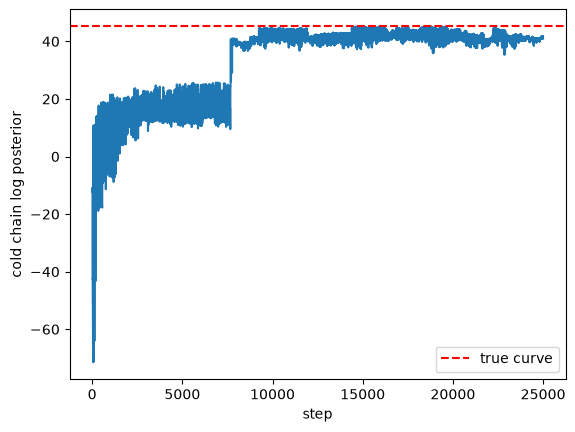

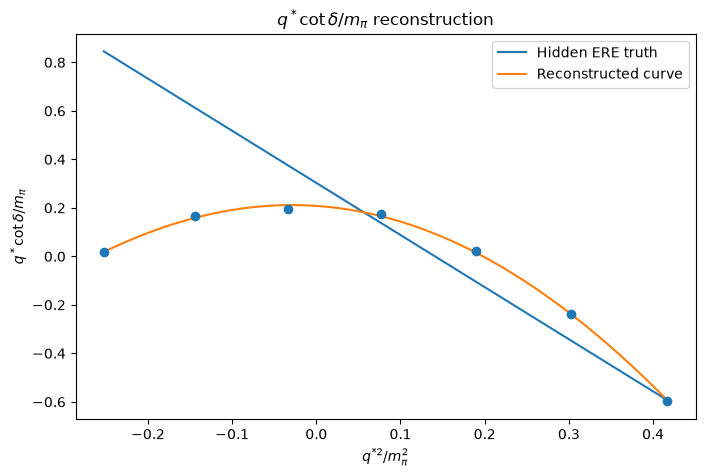

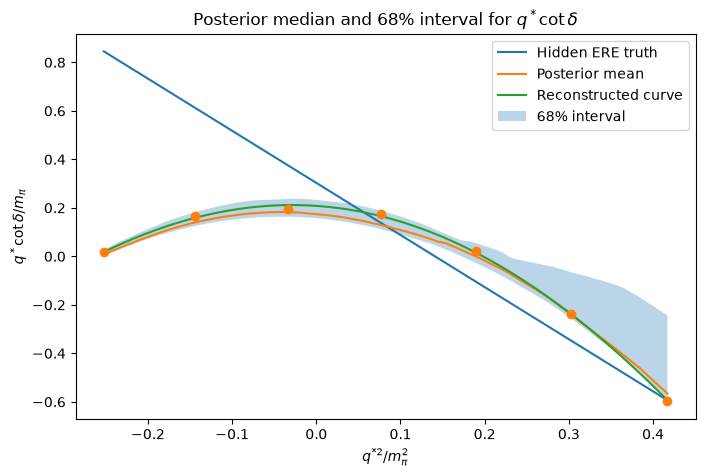

In [110]:
plot_mcmc(observed_cache_1_cov, best_cold_state_cov, cold_log_post_history_cov, samples_cov, best_cold_logpost_cov)

In [111]:
print(swap_accepts_cov / swap_attempts_cov)
best_f_knots, best_sigma, best_length_scale = best_cold_state_cov
a_true, r_true = a_r_Values[1]
true_curve_at_knots = -1/a_true + 0.5*r_true*((knots/2)**2 - m**2)



best_true_logpost = -np.inf
for test_sigma in [0.005, 0.01, 0.02, 0.03, 0.05]:
    for test_ell in [0.1, 0.2, 0.3, 0.5, 0.8]:
        ll, lp, lh = posterior_components(true_curve_at_knots, test_sigma, test_ell, observed_cache_1_cov)
        total = ll + lp + lh
        if total > best_true_logpost:
            best_true_logpost = total
            best_true_params = (test_sigma, test_ell)

print("best achievable true-curve log posterior:", best_true_logpost, "at", best_true_params)
print("best cold-chain log posterior:", best_cold_logpost_cov)
print(best_sigma, best_length_scale)

[0.9928 0.9864 0.9764 0.9488 0.9212 0.3016 0.716  0.7888 0.8444 0.8864
 0.9096 0.9288 0.3172 0.9584]
best achievable true-curve log posterior: -998.8187120730672 at (0.05, 0.3)
best cold-chain log posterior: 45.29282015509827
0.022831037611729114 0.2500370974612701


In [112]:
Kinv_best = Kinv_Grid(Ecm_grid, best_sigma, best_length_scale, best_f_knots)
for L in L_values:
    for Psq in Psq_to_nP.keys():
        key = (L, Psq)
        if key not in observed_cache_1_cov:
            continue
        E_obs_arr = observed_cache_1_cov[key]["E_obs"]
        dE_arr = observed_cache_1_cov[key]["dE"]
        E_pred_arr = find_Zeros_GPR(best_f_knots, best_sigma, best_length_scale, L, Psq, Kinv_best)
        for E_obs, dE in zip(E_obs_arr, dE_arr):
            E_pred = E_pred_arr[np.argmin(np.abs(E_pred_arr - E_obs))]
            pull = (E_obs - E_pred)/dE
            print(f"L={L}, Psq={Psq}: E_obs={E_obs:.4f}, E_pred={E_pred:.4f}, dE={dE:.5f}, pull={pull:.2f}")

L=33.72768, Psq=0: E_obs=2.0195, E_pred=2.0210, dE=0.00594, pull=-0.24
L=33.72768, Psq=0: E_obs=2.0456, E_pred=2.0475, dE=0.00659, pull=-0.29
L=33.72768, Psq=1: E_obs=2.0051, E_pred=2.0047, dE=0.00732, pull=0.06
L=33.72768, Psq=1: E_obs=2.0245, E_pred=2.0265, dE=0.00817, pull=-0.25
L=33.72768, Psq=1: E_obs=2.0549, E_pred=2.0564, dE=0.00866, pull=-0.18
L=33.72768, Psq=2: E_obs=2.0097, E_pred=2.0094, dE=0.00935, pull=0.03
L=33.72768, Psq=2: E_obs=2.0325, E_pred=2.0348, dE=0.01006, pull=-0.23
L=33.72768, Psq=2: E_obs=2.0623, E_pred=2.0633, dE=0.01058, pull=-0.10
L=33.72768, Psq=3: E_obs=2.0124, E_pred=2.0125, dE=0.01137, pull=-0.00
L=33.72768, Psq=3: E_obs=2.0468, E_pred=2.0502, dE=0.01213, pull=-0.29
L=33.72768, Psq=4: E_obs=2.0193, E_pred=2.0208, dE=0.01296, pull=-0.12
L=33.72768, Psq=4: E_obs=2.0451, E_pred=2.0471, dE=0.01336, pull=-0.15
L=33.72768, Psq=4: E_obs=2.0795, E_pred=2.0795, dE=0.01383, pull=-0.00
